Ziel dieses Notebooks ist die Sentimentanalyse der Lügenpresse-Synonyme um zu ermitteln ob Lügenpresse-Synonyme tendenziell in eher positiven, negativen oder neutralen Kontexten benutzt wurden und ob sich unterschiede zwischen den vier Synonymen abzeichnen.

In [ ]:
import pandas as pd
import re
from collections import Counter # Counter is still useful if you want to keep track of counts

# 1. Load the original data (df)
df = pd.read_excel('/content/Kopie von Synonyme_2751569-2.xlsx')

# 2. Convert text to lowercase for case-insensitive searching
df['plainpagefulltext'] = df['plainpagefulltext'].str.lower()

# 3. Define the full synonym list (as per cell nGu0G-MO9QVU)
synonyme = ["lüge",
    "lügenpresse",
    "falschmeldung",
    "lügenblatt",
    "lügenblätter",
    "hetzblatt",
    "hetzpresse",
    "schmierblatt",
    "schmierpresse",
    "pamphletpresse",
    "parteipresse",
    "demagogenpresse",
    "revolutionspresse",
    "radikale presse",
    "ultraradikale presse",
    "jüdische presse",
    "judenpresse",
    "liberale presse",
    "freimaurerpresse",
    "logenpresse",
    "pressunfug",
    "wühlerpresse",
    "gegenpresse",
    "zeitungsgeschrei",
    "journalistenpack",
    "tintenkleckserei",

    "lügenpreſſe",
    "falſchmeldung",
    "hetzpreſſe",
    "schmierblatt",
    "schmierpreſſe",
    "pamphletpreſſe",
    "parteipreſſe",
    "demagogenpreſſe",
    "revolutionſpreſſe",
    "radikale preſſe",
    "ultraradikale preſſe",
    "jüdiſche preſſe",
    "judenpreſſe",
    "liberale preſſe",
    "freimaurerpreſſe",
    "logenpreſſe",
    "preſſunfug",
    "wühlerpreſſe",
    "gegenpreſſe",
    "zeitungſgeſchrei",
    "journaliſtenpack",
    "tintenkleckſerei",

    "luge",
    "lugenpresse",
    "lugenblatter",
    "judische presse",
    "wuhlerpresse",

    "lugenpreſſe",
    "judiſche preſſe",
    "wuhlerpreſſe",
]

# 4. Filter the main DataFrame to create df_synonyme (pages containing any synonym)
pattern = '|'.join(synonyme)
df_synonyme = df[df['plainpagefulltext'].str.contains(pattern, na=False)].copy() # .copy() to prevent SettingWithCopyWarning
# --- End re-creation ---

# Define the 26 canonical categories and their associated variants
# This ensures exactly 26 categories as requested and correctly groups variations.
canonical_categories_map = {
    "lüge": ["lüge", "luge"],
    "lügenpresse": ["lügenpresse", "lügenpreſſe", "lugenpresse", "lugenpreſſe"],
    "falschmeldung": ["falschmeldung", "falſchmeldung"],
    "lügenblatt": ["lügenblatt"],
    "lügenblätter": ["lügenblätter", "lugenblatter"],
    "hetzblatt": ["hetzblatt"],
    "hetzpresse": ["hetzpresse", "hetzpreſſe"],
    "schmierblatt": ["schmierblatt"],
    "schmierpresse": ["schmierpresse", "schmierpreſſe"],
    "pamphletpresse": ["pamphletpresse", "pamphletpreſſe"],
    "parteipresse": ["parteipresse", "parteipreſſe"],
    "demagogenpresse": ["demagogenpresse", "demagogenpreſſe"],
    "revolutionspresse": ["revolutionspresse", "revolutionſpreſſe"],
    "radikale presse": ["radikale presse", "radikale preſſe"],
    "ultraradikale presse": ["ultraradikale presse", "ultraradikale preſſe"],
    "jüdische presse": ["jüdische presse", "jüdiſche preſſe", "judische presse", "judiſche preſſe"],
    "judenpresse": ["judenpresse", "judenpreſſe"],
    "liberale presse": ["liberale presse", "liberale preſſe"],
    "freimaurerpresse": ["freimaurerpresse", "freimaurerpreſſe"],
    "logenpresse": ["logenpresse", "logenpreſſe"],
    "pressunfug": ["pressunfug", "preſſunfug"],
    "wühlerpresse": ["wühlerpresse", "wühlerpreſse", "wuhlerpresse", "wuhlerpreſſe"],
    "gegenpresse": ["gegenpresse", "gegenpreſſe"],
    "zeitungsgeschrei": ["zeitungsgeschrei", "zeitungſgeſchrei"],
    "journalistenpack": ["journalistenpack", "journaliſtenpack"],
    "tintenkleckserei": ["tintenkleckserei", "tintenkleckſerei"]
}

# Compile regex patterns for each canonical category for efficient searching.
# Patterns are constructed to match substrings (consistent with initial df_synonyme filtering).
compiled_patterns = {}
for canonical_name, variants in canonical_categories_map.items():
    variant_regexes = []
    for var in variants:
        # Match directly without strict word boundaries to be consistent with str.contains
        variant_regexes.append(re.escape(var))
    compiled_patterns[canonical_name] = re.compile('|'.join(variant_regexes))

# --- MODIFIED PART FOR SENTIMENT ANALYSIS PREPARATION ---

# Prepare a list to store data for sentiment analysis
sentiment_analysis_data = []

# Iterate through each row in df_synonyme
for index, row in df_synonyme.iterrows():
    text = row['plainpagefulltext']

    # Find all canonical synonyms present in the current text
    # Use a set to avoid adding the same (text, synonym) pair multiple times if a synonym appears more than once in a text
    found_on_page_canonicals = set()
    for canonical_name, pattern_compiled in compiled_patterns.items():
        if pattern_compiled.search(text):
            found_on_page_canonicals.add(canonical_name)

    # For each unique canonical synonym found on this page, add the text and the synonym to our data
    for canonical in found_on_page_canonicals:
        sentiment_analysis_data.append({
            'text_context': text,
            'canonical_synonym': canonical
        })

# Convert the list of dictionaries to a DataFrame for easier handling
df_sentiment_analysis = pd.DataFrame(sentiment_analysis_data)

# Display the head of the new DataFrame to verify
print("DataFrame for Sentiment Analysis:")
print(df_sentiment_analysis.head())
print(f"Total entries for sentiment analysis: {len(df_sentiment_analysis)}")


DataFrame for Sentiment Analysis:
                                        text_context canonical_synonym
0  auch in rheinheſſen gelten. dieſe worte ſchlug...              lüge
1  739 beruht nur auf gerüchten, die noch der beſ...              lüge
2  743 trachtungen gehen langen schilderungen und...              lüge
3  z95 ausführungen ſeines vorgängers und fährt d...              lüge
4  alle poſtämter nehmen be ſtellungen auf die de...              lüge
Total entries for sentiment analysis: 1116


In [ ]:
!pip install transformers torch --quiet

In [ ]:
import pandas as pd
from transformers import pipeline

# 2. Sentiment-Modell laden
# Multilinguales Modell (funktioniert gut für Deutsch)
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def map_sentiment(label):
    """
    Modell gibt 1–5 Sterne zurück:
    1-2 = negativ
    3 = neutral
    4-5 = positiv
    """
    stars = int(label.split()[0])  # z.B. "4 stars" -> 4

    if stars <= 2:
        return "negativ"
    elif stars == 3:
        return "neutral"
    else:
        return "positiv"


In [ ]:
results = []

for idx, row in df_sentiment_analysis.iterrows():
    text = row['text_context']
    synonym = row['canonical_synonym']

    # Optional: Text kürzen (BERT hat Limit ~512 Tokens)
    text_short = text[:512]

    try:
        prediction = sentiment_pipeline(text_short)[0]
        sentiment = map_sentiment(prediction['label'])
    except:
        sentiment = "unknown"

    results.append({
        "text_context": text,
        "canonical_synonym": synonym,
        "sentiment": sentiment
    })


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
df_sentiment_labeled = pd.DataFrame(results)

print(df_sentiment_labeled.head())
print("\nVerteilung:")
print(df_sentiment_labeled['sentiment'].value_counts())

                                        text_context canonical_synonym  \
0  auch in rheinheſſen gelten. dieſe worte ſchlug...              lüge   
1  739 beruht nur auf gerüchten, die noch der beſ...              lüge   
2  743 trachtungen gehen langen schilderungen und...              lüge   
3  z95 ausführungen ſeines vorgängers und fährt d...              lüge   
4  alle poſtämter nehmen be ſtellungen auf die de...              lüge   

  sentiment  
0   negativ  
1   negativ  
2   negativ  
3   negativ  
4   negativ  

Verteilung:
sentiment
negativ    978
positiv    118
neutral     20
Name: count, dtype: int64


In [ ]:
summary = pd.crosstab(
    df_sentiment_labeled['canonical_synonym'],
    df_sentiment_labeled['sentiment']
)

print(summary)

sentiment          negativ  neutral  positiv
canonical_synonym                           
liberale presse         10        0        1
lüge                   954       20      116
lügenblätter             1        0        1
radikale presse         13        0        0


### Überblick über die Sentimentverteilung
Nachdem die Sentimentanalyse abgeschlossen ist, schauen wir uns die Verteilung der verschiedenen Stimmungen ('positiv', 'negativ', 'neutral') über alle analysierten Synonyme auch noch mal graphisch an.

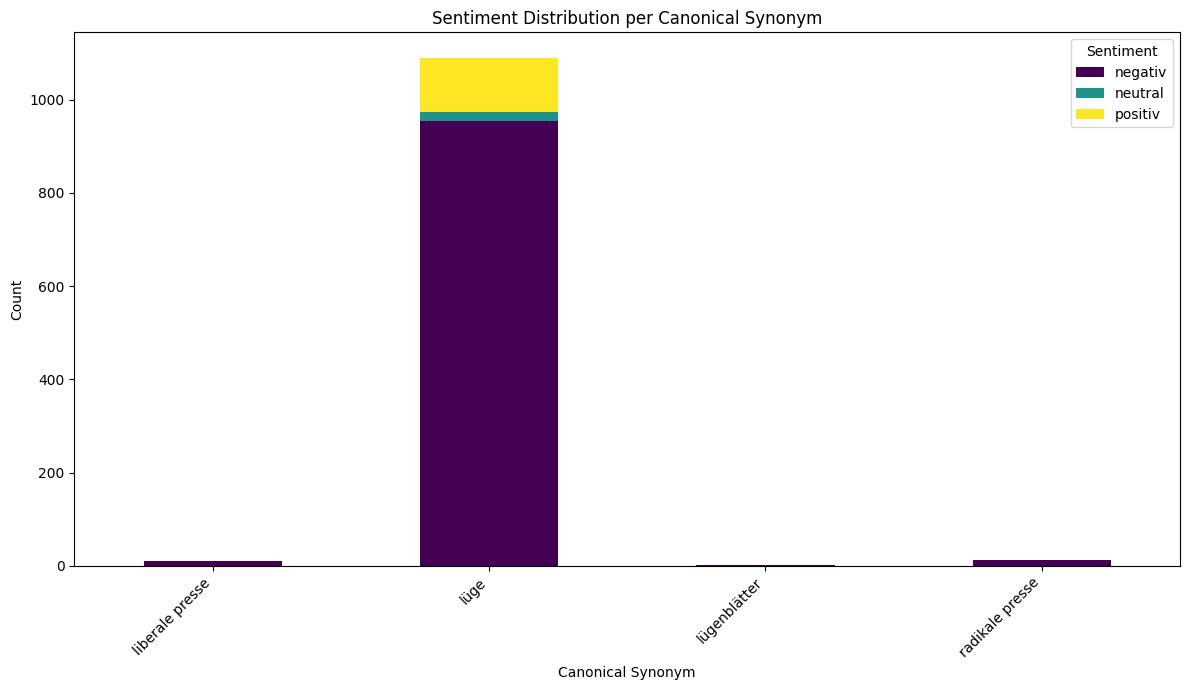

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame checks

# Ensure 'summary' DataFrame exists
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    # Plotting the summary DataFrame as a stacked bar chart
    # Using .plot.bar() for convenience
    summary.plot.bar(stacked=True, figsize=(12, 7), cmap='viridis')
    plt.title('Sentiment Distribution per Canonical Synonym')
    plt.xlabel('Canonical Synonym')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.legend(title='Sentiment')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("DataFrame 'summary' ist nicht verfügbar oder leer. Bitte stellen Sie sicher, dass die vorherigen Zellen korrekt ausgeführt wurden und Daten generiert wurden.")

### Prozentuale Sentimentverteilung pro Synonym
Um einen besseren Vergleich zwischen den Synonymen zu ermöglichen, berechnen wir die prozentuale Verteilung der Stimmungen (positiv, negativ, neutral) für jedes Synonym. Dabei ist noch einmal deutlicher zu erkennen das ein Großteil der Nennungen in allen Kategorien negativ war. Und selbst in lügenblätter wo ja "nur" 50% negativ waren war die sample size so klein dass es kaum möglich ist aussagekräftige statistische Schlussfolgerungen zu ziehen (da nur eine Falscheinsortierung die Ergebnisse absolut verzerrt)

In [ ]:
# Berechne die prozentuale Verteilung pro Zeile (Synonym)
summary_percentage = summary.div(summary.sum(axis=1), axis=0) * 100

print("Prozentuale Sentimentverteilung pro kanonischem Synonym:")
display(summary_percentage.round(2)) # Zeige Prozentsätze gerundet auf 2 Dezimalstellen

Prozentuale Sentimentverteilung pro kanonischem Synonym:


sentiment,negativ,neutral,positiv
canonical_synonym,,,
liberale presse,90.91,0.00,9.09
lüge,87.52,1.83,10.64
lügenblätter,50.00,0.00,50.00
radikale presse,100.00,0.00,0.00
